# 목적 : 비행기 승객의 만족도 분석

# 데이터 : kaggle의 비행기 승객 만족도 설문조사 데이터

## 라이브러리 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm

In [2]:
path = 'C:/Users/TS/Downloads/archive/train.csv'
df_train = pd.read_csv(path,index_col = 0)
df_train.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 탐색적 데이터 분석(EDA)

In [3]:
print("shape : ",df_train.shape)
print("colunms : ", df_train.columns)

shape :  (103904, 24)
colunms :  Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 no

In [5]:
df_train.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [6]:
df_train.isnull().sum()/len(df_train)  *100

id                                   0.000000
Gender                               0.000000
Customer Type                        0.000000
Age                                  0.000000
Type of Travel                       0.000000
Class                                0.000000
Flight Distance                      0.000000
Inflight wifi service                0.000000
Departure/Arrival time convenient    0.000000
Ease of Online booking               0.000000
Gate location                        0.000000
Food and drink                       0.000000
Online boarding                      0.000000
Seat comfort                         0.000000
Inflight entertainment               0.000000
On-board service                     0.000000
Leg room service                     0.000000
Baggage handling                     0.000000
Checkin service                      0.000000
Inflight service                     0.000000
Cleanliness                          0.000000
Departure Delay in Minutes        

### 시각화

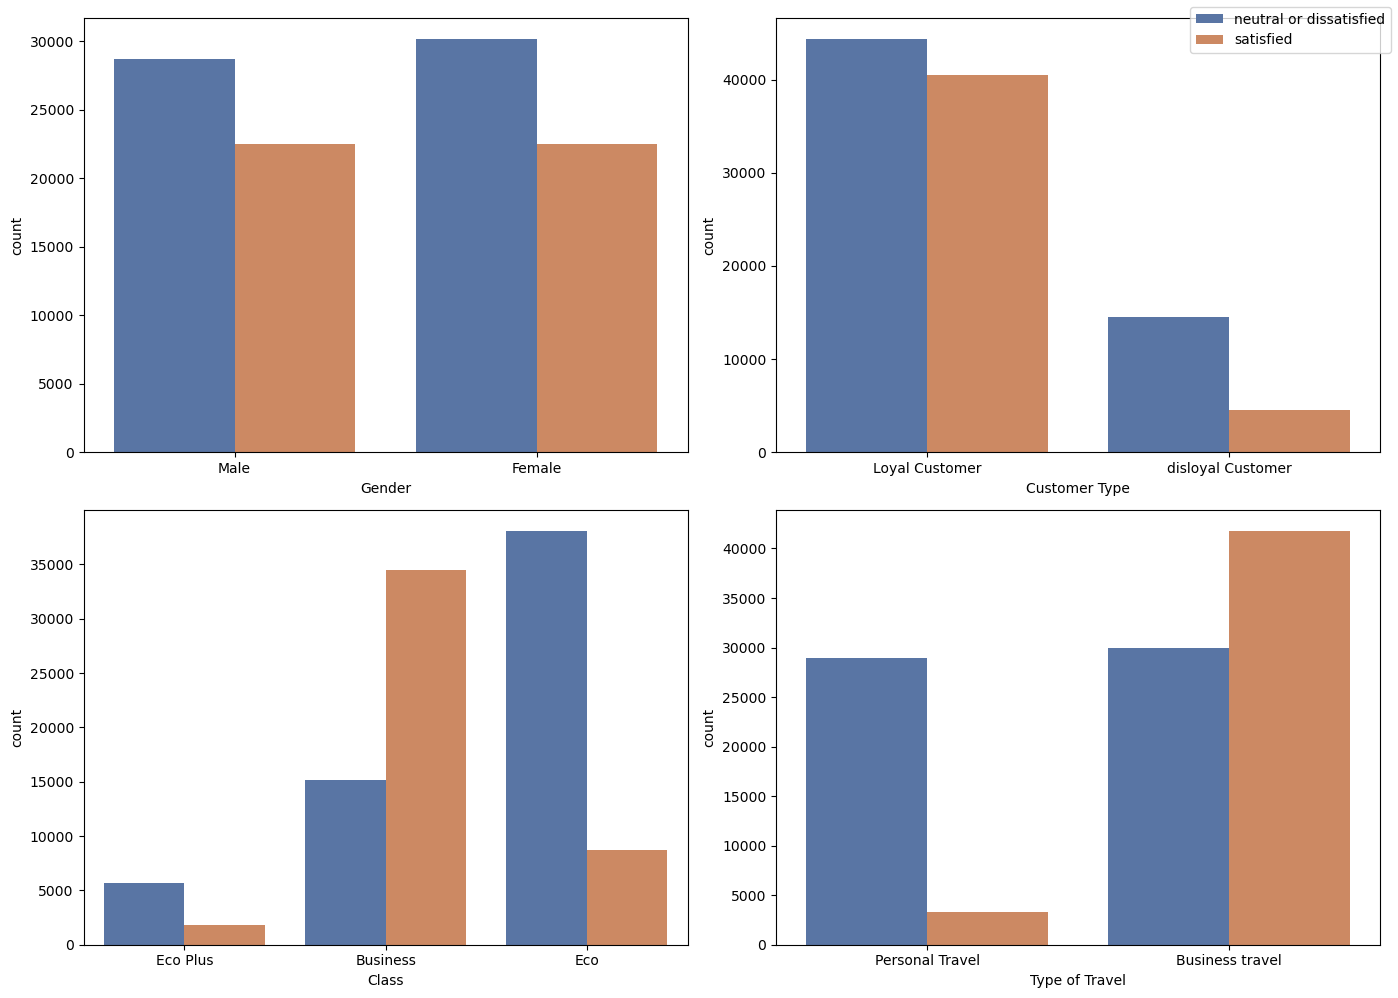

In [7]:
hue_order = ["neutral or dissatisfied", "satisfied"]

palette = {
    "neutral or dissatisfied": "#4C72B0",
    "satisfied": "#DD8452"
}

fig, axes = plt.subplots(2,2, figsize=(14, 10))
sns.countplot(ax = axes[0,0],data = df_train, x = "Gender", hue = "satisfaction",palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[0,1],data = df_train, x = "Customer Type", hue = "satisfaction",palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[1,0],data = df_train, x = "Class", hue = "satisfaction",palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[1,1],data = df_train, x = "Type of Travel", hue = "satisfaction",palette = palette, hue_order = hue_order)

for ax in axes.flat:
    ax.legend_.remove()


handles, labels = axes[1,1].get_legend_handles_labels()


fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

<Axes: xlabel='satisfaction', ylabel='Departure Delay in Minutes'>

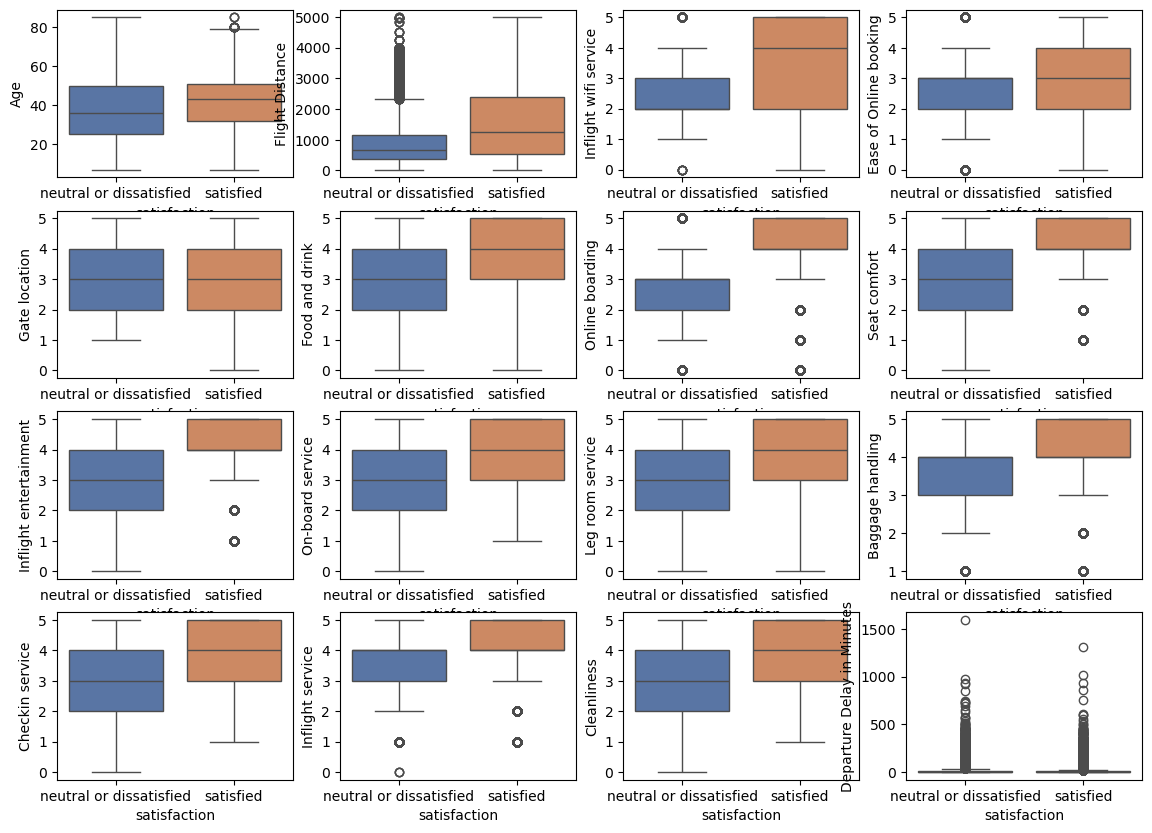

In [8]:
palette = {
    "neutral or dissatisfied": "#4C72B0",
    "satisfied": "#DD8452"
}

fig, axes = plt.subplots(4,4, figsize=(14, 10))
sns.boxplot(ax = axes[0,0], data = df_train, x = "satisfaction", y = "Age", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[0,1], data = df_train, x = "satisfaction", y = "Flight Distance",hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[0,2], data = df_train, x = "satisfaction", y = "Inflight wifi service", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[0,3], data = df_train, x = "satisfaction", y = "Ease of Online booking", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[1,0], data = df_train, x = "satisfaction", y = "Gate location", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[1,1], data = df_train, x = "satisfaction", y = "Food and drink", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[1,2], data = df_train, x = "satisfaction", y = "Online boarding", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[1,3], data = df_train, x = "satisfaction", y = "Seat comfort", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[2,0], data = df_train, x = "satisfaction", y = "Inflight entertainment", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[2,1], data = df_train, x = "satisfaction", y = "On-board service", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[2,2], data = df_train, x = "satisfaction", y = "Leg room service", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[2,3], data = df_train, x = "satisfaction", y = "Baggage handling", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[3,0], data = df_train, x = "satisfaction", y = "Checkin service", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[3,1], data = df_train, x = "satisfaction", y = "Inflight service", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[3,2], data = df_train, x = "satisfaction", y = "Cleanliness", hue ="satisfaction",palette = palette,legend=False)
sns.boxplot(ax = axes[3,3], data = df_train, x = "satisfaction", y = "Departure Delay in Minutes", hue ="satisfaction",palette = palette,legend=False)

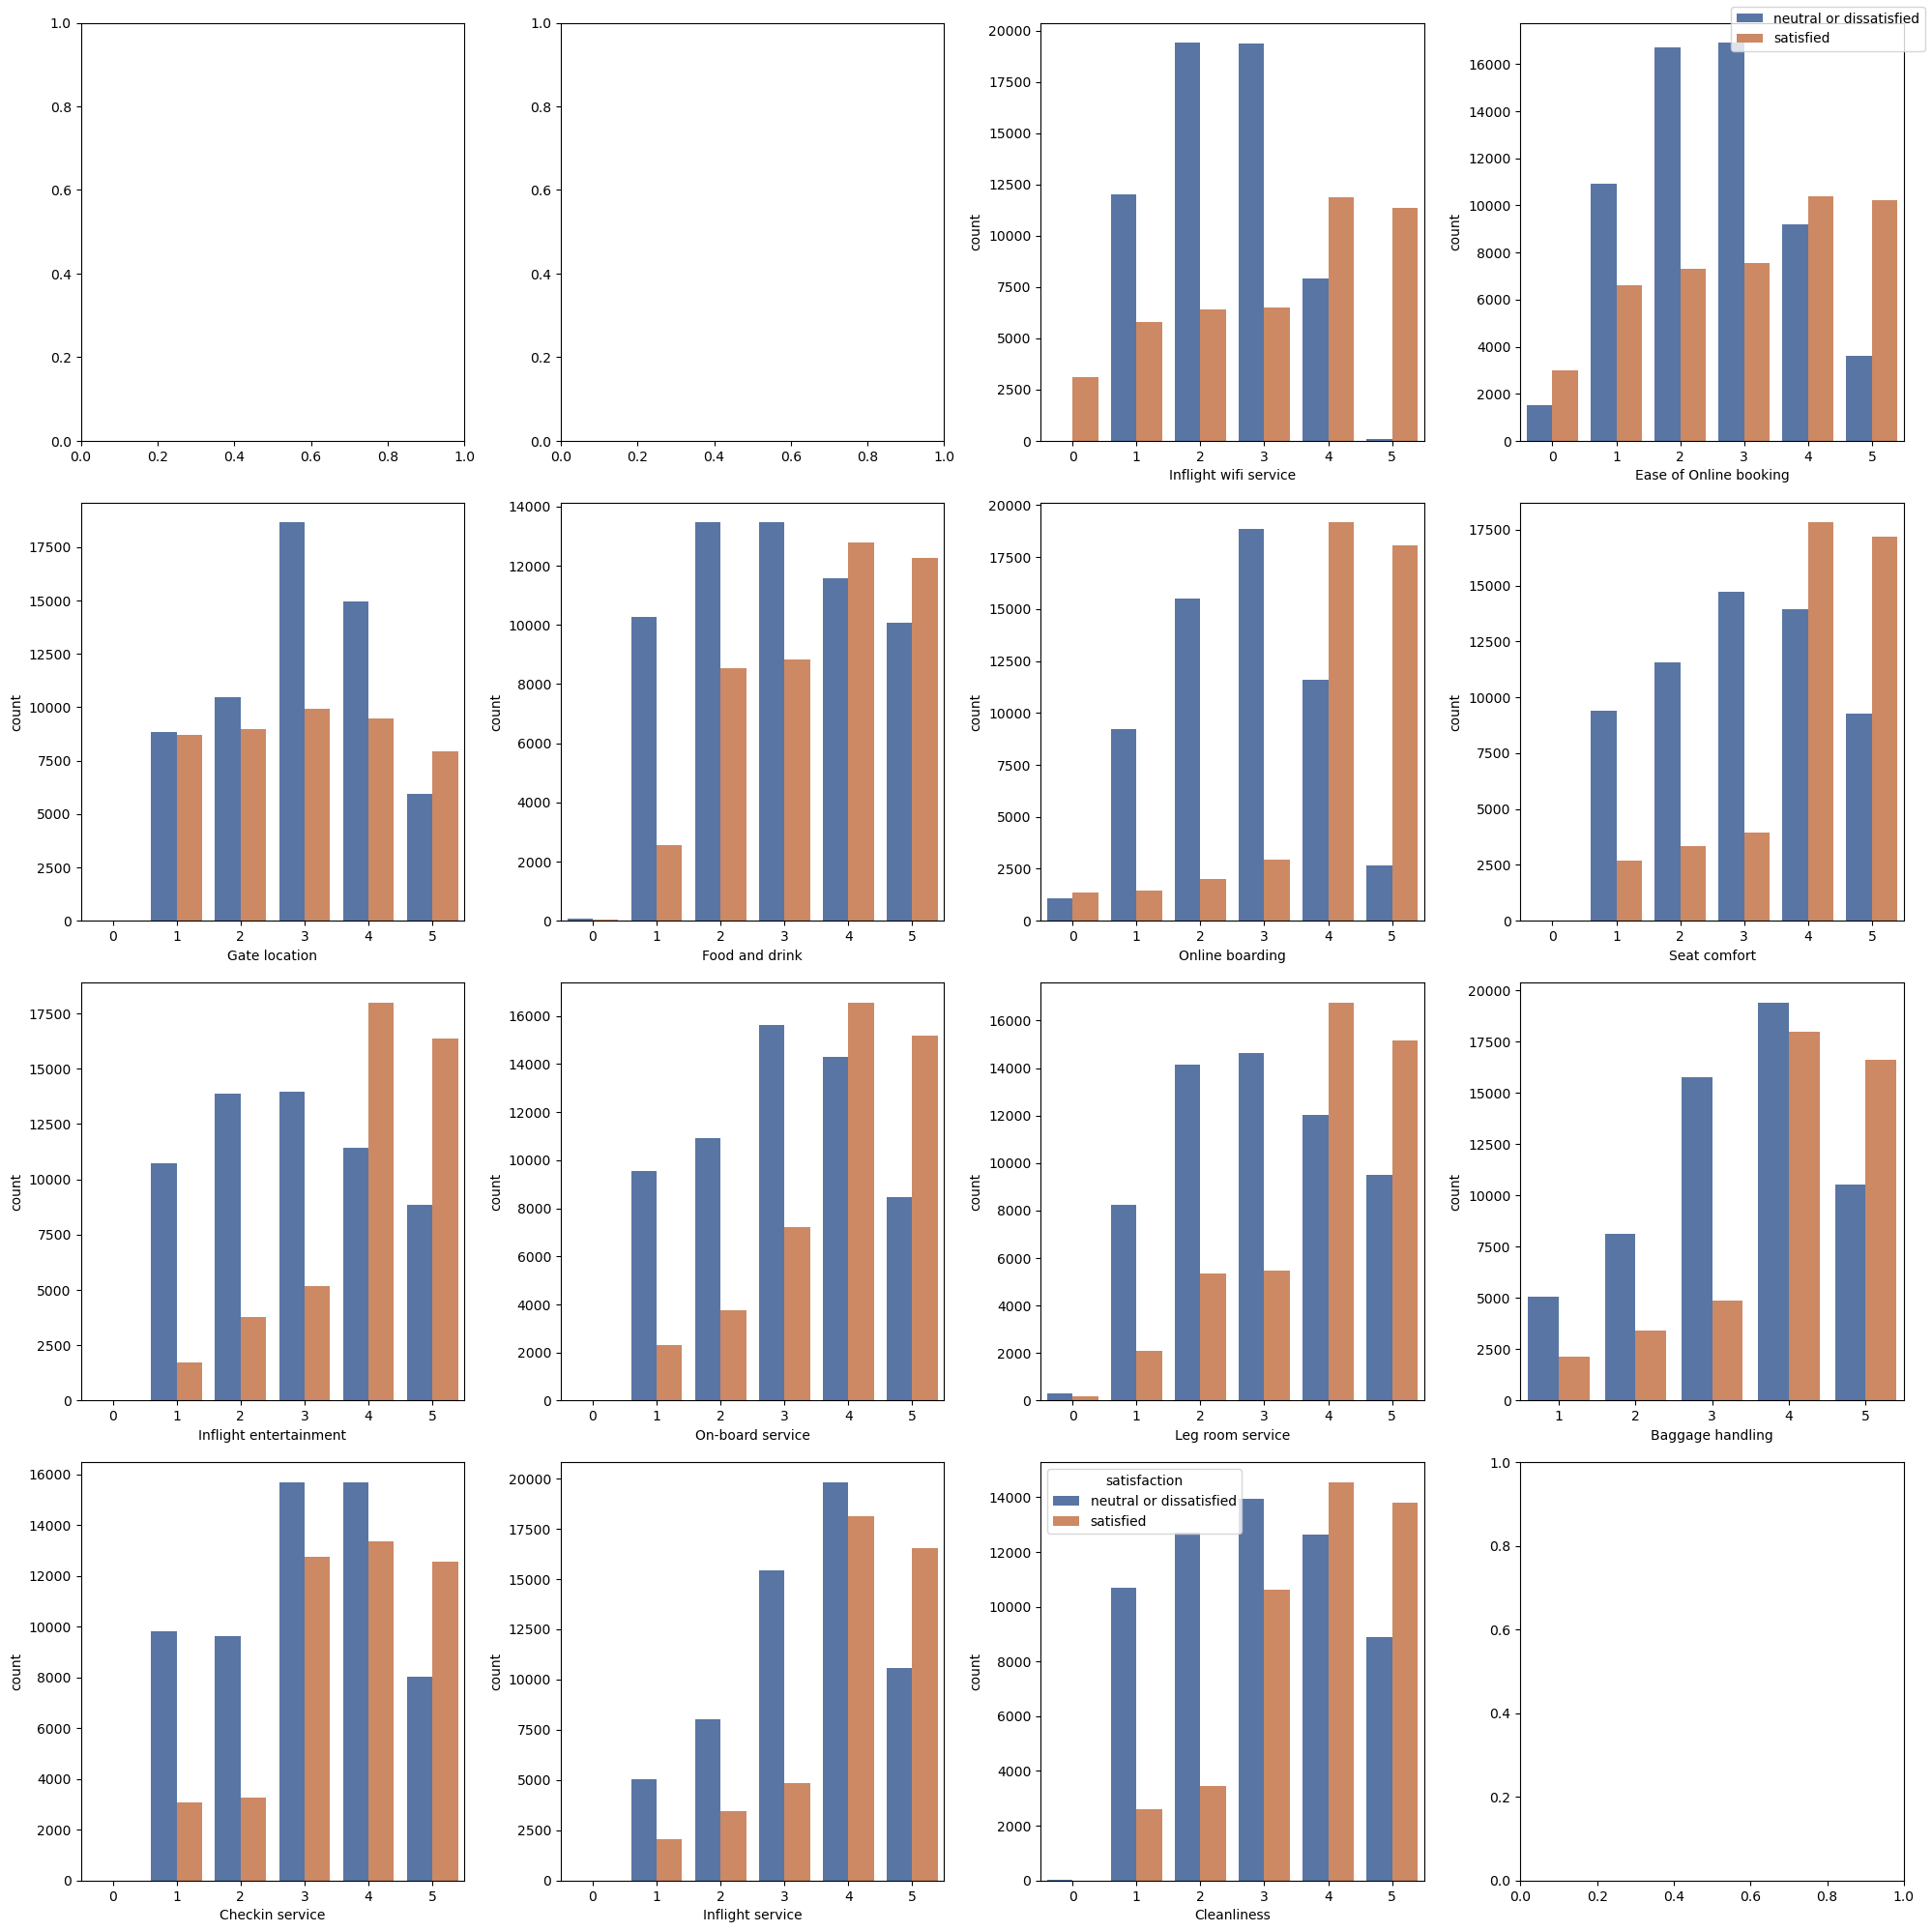

In [9]:
hue_order = ["neutral or dissatisfied", "satisfied"]


palette = {
    "neutral or dissatisfied": "#4C72B0",
    "satisfied": "#DD8452"
}

fig, axes = plt.subplots(4,4, figsize=(20, 20))
# sns.countplot(ax = axes[0,0], data = df_train, hue = "satisfaction", x = "Age", palette = palette, hue_order = hue_order)
# sns.countplot(ax = axes[0,1], data = df_train, hue = "satisfaction", x = "Flight Distance", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[0,2], data = df_train, hue = "satisfaction", x = "Inflight wifi service", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[0,3], data = df_train, hue = "satisfaction", x = "Ease of Online booking", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[1,0], data = df_train, hue = "satisfaction", x = "Gate location", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[1,1], data = df_train, hue = "satisfaction", x = "Food and drink", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[1,2], data = df_train, hue = "satisfaction", x = "Online boarding", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[1,3], data = df_train, hue = "satisfaction", x = "Seat comfort", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[2,0], data = df_train, hue = "satisfaction", x = "Inflight entertainment", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[2,1], data = df_train, hue = "satisfaction", x = "On-board service", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[2,2], data = df_train, hue = "satisfaction", x = "Leg room service", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[2,3], data = df_train, hue = "satisfaction", x = "Baggage handling", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[3,0], data = df_train, hue = "satisfaction", x = "Checkin service", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[3,1], data = df_train, hue = "satisfaction", x = "Inflight service", palette = palette, hue_order = hue_order)
sns.countplot(ax = axes[3,2], data = df_train, hue = "satisfaction", x = "Cleanliness", palette = palette, hue_order = hue_order)
# sns.countplot(ax = axes[3,3], data = df_train, hue = "satisfaction", x = "Departure Delay in Minutes", palette = palette, hue_order = hue_order)

##legned
for ax in axes.flat[2:-2]:
    ax.legend_.remove()


handles, labels = axes[1,1].get_legend_handles_labels()


fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

In [10]:
df_train.drop(['id'],axis = 1, inplace = True)

## 모델 학습

### 베이스라인모델

In [11]:
# X = df_train.drop(['Arrival Delay in Minutes','satisfaction_satisfied'],axis = 1)
# y = df_train['satisfaction_satisfied']

In [12]:
# X = X.astype(float)
# X = sm.add_constant(X)

# model = sm.Logit(y, X).fit()
# print(model.summary())

In [13]:
# df_train

### 모델 정확성 높이기

In [14]:
def categorize_score(x):
    if x <= 1:
        return "bad"
    elif x <= 3:
        return "normal"
    else:  # 4~5
        return "good"
def categorize_score2(x):
    if x <= 3:
        return "bad or normal"
    else:  # 4~5
        return "good"


df_train["Food and drink"] = df_train["Food and drink"].apply(categorize_score)
df_train["Inflight wifi service"] = df_train["Inflight wifi service"].apply(categorize_score2)
df_train["Ease of Online booking"] = df_train["Ease of Online booking"].apply(categorize_score2)
df_train["Online boarding"] = df_train["Online boarding"].apply(categorize_score2)
df_train["Seat comfort"] = df_train["Seat comfort"].apply(categorize_score2)
df_train["Inflight entertainment"] = df_train["Inflight entertainment"].apply(categorize_score2)
df_train["On-board service"] = df_train["On-board service"].apply(categorize_score2)
df_train["Leg room service"] = df_train["Leg room service"].apply(categorize_score)
df_train["Baggage handling"] = df_train["Baggage handling"].apply(categorize_score2)
df_train["Checkin service"] = df_train["Checkin service"].apply(categorize_score)
df_train["Inflight service"] = df_train["Inflight service"].apply(categorize_score2)
df_train["Cleanliness"] = df_train["Cleanliness"].apply(categorize_score)



# 더미변수 생성
df_train_dummies = pd.get_dummies(df_train, drop_first=True)

In [15]:
df_train_dummies.drop(['Arrival Delay in Minutes'],axis = 1,inplace =True)

In [16]:
X = df_train_dummies.drop(['satisfaction_satisfied'],axis = 1)
y = df_train_dummies['satisfaction_satisfied']

In [17]:
X = X.astype(float)
X = sm.add_constant(X)

model3 = sm.Logit(y, X).fit()
print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.294898
         Iterations 7
                             Logit Regression Results                             
Dep. Variable:     satisfaction_satisfied   No. Observations:               103904
Model:                              Logit   Df Residuals:                   103877
Method:                               MLE   Df Model:                           26
Date:                    Sun, 22 Feb 2026   Pseudo R-squ.:                  0.5690
Time:                            19:15:03   Log-Likelihood:                -30641.
converged:                           True   LL-Null:                       -71094.
Covariance Type:                nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                         